In [1]:
import os, sys
# Ensure working directory is the repo root so asvFormula package and relative paths work correctly
if os.path.basename(os.getcwd()) == 'experiments':
    os.chdir('..')
repo_root = os.getcwd()
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

# Topological Sort Comparison: `randomTopoSorts` vs `mcmcTopoSorts`

This notebook benchmarks two methods for sampling topological sorts:
- **`randomTopoSorts`**: exact weighted sampling using counts of linear extensions (works on poly-trees)
- **`mcmcTopoSorts`**: MCMC-based approximate sampling following Huber (1998) (works on arbitrary DAGs)

We compare runtime across:
1. Different **graph types** with increasing **number of nodes**
2. Different **number of samples** on a fixed graph

In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from asvFormula.topoSorts.randomTopoSortsGeneration import randomTopoSorts, mcmcTopoSorts
from asvFormula.digraph import naiveBayes, balancedTree

sns.set_theme(style='whitegrid')

## Graph Factories

We test on three graph families:
- **Chain**: a simple directed path 0→1→2→…→n-1
- **Balanced binary tree**: root fans out hierarchically
- **Naive Bayes**: one root connected to all other nodes

In [4]:
def make_chain(n: int) -> nx.DiGraph:
    """Directed path graph 0->1->...->n-1."""
    g = nx.DiGraph()
    g.add_nodes_from(range(n))
    g.add_edges_from((i, i + 1) for i in range(n - 1))
    return g

def make_balanced_tree(n: int) -> nx.DiGraph:
    """Balanced binary tree with enough height to have at least n nodes."""
    height = max(2, int(np.ceil(np.log2(n + 1))) + 1)
    g = balancedTree(height, branchingFactor=2)
    # Trim to exactly n nodes (keep first n in topological order)
    nodes_to_keep = list(nx.topological_sort(g))[:n]
    return g.subgraph(nodes_to_keep).copy()

def make_naive_bayes(n: int) -> nx.DiGraph:
    """Naive Bayes graph: root -> all other nodes."""
    return naiveBayes(n)

graph_factories = {
    'Chain': make_chain,
    'Balanced Tree': make_balanced_tree,
    'Naive Bayes': make_naive_bayes,
}

## Experiment 1: Scaling with Number of Nodes

Fix number of samples at 200, vary graph size.

In [5]:
NUM_SAMPLES = 200
NODE_COUNTS = [4, 6, 8, 10, 12, 14]

records = []

for graph_name, factory in graph_factories.items():
    for n in NODE_COUNTS:
        g = factory(n)
        actual_n = g.number_of_nodes()

        # Time randomTopoSorts
        t0 = time.perf_counter()
        randomTopoSorts(g, NUM_SAMPLES)
        t_random = time.perf_counter() - t0

        # Time mcmcTopoSorts
        t0 = time.perf_counter()
        mcmcTopoSorts(g, NUM_SAMPLES)
        t_mcmc = time.perf_counter() - t0

        records.append({
            'Graph': graph_name,
            'Nodes': actual_n,
            'randomTopoSorts (s)': t_random,
            'mcmcTopoSorts (s)': t_mcmc,
        })
        print(f"{graph_name:15s} n={actual_n:3d}  random={t_random:.3f}s  mcmc={t_mcmc:.3f}s")

df_nodes = pd.DataFrame(records)

Chain           n=  4  random=0.003s  mcmc=0.018s
Chain           n=  6  random=0.001s  mcmc=0.046s
Chain           n=  8  random=0.001s  mcmc=0.100s
Chain           n= 10  random=0.001s  mcmc=0.229s
Chain           n= 12  random=0.002s  mcmc=0.342s
Chain           n= 14  random=0.005s  mcmc=0.625s
Balanced Tree   n=  4  random=0.000s  mcmc=0.012s
Balanced Tree   n=  6  random=0.001s  mcmc=0.039s
Balanced Tree   n=  8  random=0.004s  mcmc=0.102s
Balanced Tree   n= 10  random=0.018s  mcmc=0.193s
Balanced Tree   n= 12  random=0.028s  mcmc=0.324s
Balanced Tree   n= 14  random=0.059s  mcmc=0.543s
Naive Bayes     n=  4  random=0.001s  mcmc=0.014s
Naive Bayes     n=  6  random=0.002s  mcmc=0.046s
Naive Bayes     n=  8  random=0.013s  mcmc=0.109s
Naive Bayes     n= 10  random=0.036s  mcmc=0.206s
Naive Bayes     n= 12  random=0.091s  mcmc=0.358s
Naive Bayes     n= 14  random=0.342s  mcmc=0.509s


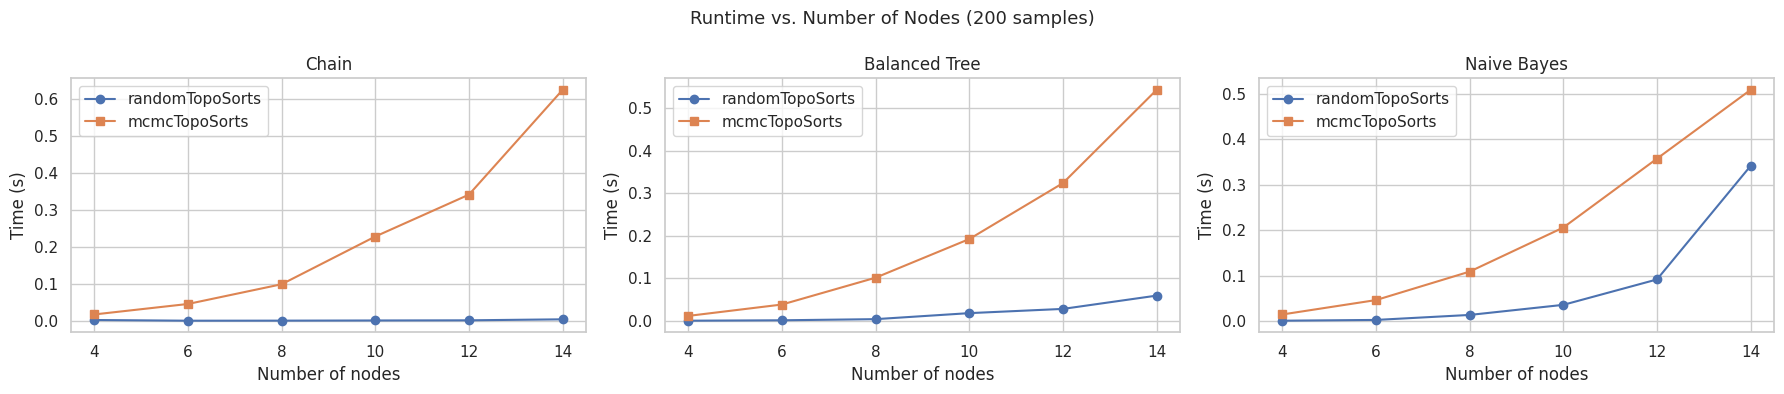

In [6]:
fig, axes = plt.subplots(1, len(graph_factories), figsize=(6 * len(graph_factories), 4), sharey=False)

for ax, (graph_name, _) in zip(axes, graph_factories.items()):
    sub = df_nodes[df_nodes['Graph'] == graph_name]
    ax.plot(sub['Nodes'], sub['randomTopoSorts (s)'], marker='o', label='randomTopoSorts')
    ax.plot(sub['Nodes'], sub['mcmcTopoSorts (s)'], marker='s', label='mcmcTopoSorts')
    ax.set_title(graph_name)
    ax.set_xlabel('Number of nodes')
    ax.set_ylabel('Time (s)')
    ax.legend()

fig.suptitle(f'Runtime vs. Number of Nodes ({NUM_SAMPLES} samples)', fontsize=13)
plt.tight_layout()
plt.show()

## Experiment 2: Scaling with Number of Samples

Fix a moderate-size graph (n=8) for each type, vary the number of requested samples.

In [7]:
FIXED_N = 8
SAMPLE_COUNTS = [10, 50, 100, 250, 500, 1000]

records_samples = []

for graph_name, factory in graph_factories.items():
    g = factory(FIXED_N)
    actual_n = g.number_of_nodes()

    for k in SAMPLE_COUNTS:
        t0 = time.perf_counter()
        randomTopoSorts(g, k)
        t_random = time.perf_counter() - t0

        t0 = time.perf_counter()
        mcmcTopoSorts(g, k)
        t_mcmc = time.perf_counter() - t0

        records_samples.append({
            'Graph': graph_name,
            'Samples': k,
            'randomTopoSorts (s)': t_random,
            'mcmcTopoSorts (s)': t_mcmc,
        })
        print(f"{graph_name:15s} k={k:5d}  random={t_random:.3f}s  mcmc={t_mcmc:.3f}s")

df_samples = pd.DataFrame(records_samples)

Chain           k=   10  random=0.001s  mcmc=0.006s
Chain           k=   50  random=0.001s  mcmc=0.031s
Chain           k=  100  random=0.001s  mcmc=0.055s
Chain           k=  250  random=0.001s  mcmc=0.125s
Chain           k=  500  random=0.002s  mcmc=0.242s
Chain           k= 1000  random=0.004s  mcmc=0.464s
Balanced Tree   k=   10  random=0.002s  mcmc=0.006s
Balanced Tree   k=   50  random=0.003s  mcmc=0.023s
Balanced Tree   k=  100  random=0.004s  mcmc=0.046s
Balanced Tree   k=  250  random=0.005s  mcmc=0.129s
Balanced Tree   k=  500  random=0.007s  mcmc=0.253s
Balanced Tree   k= 1000  random=0.007s  mcmc=0.493s
Naive Bayes     k=   10  random=0.003s  mcmc=0.006s
Naive Bayes     k=   50  random=0.005s  mcmc=0.024s
Naive Bayes     k=  100  random=0.010s  mcmc=0.047s
Naive Bayes     k=  250  random=0.013s  mcmc=0.125s
Naive Bayes     k=  500  random=0.024s  mcmc=0.259s
Naive Bayes     k= 1000  random=0.033s  mcmc=0.491s


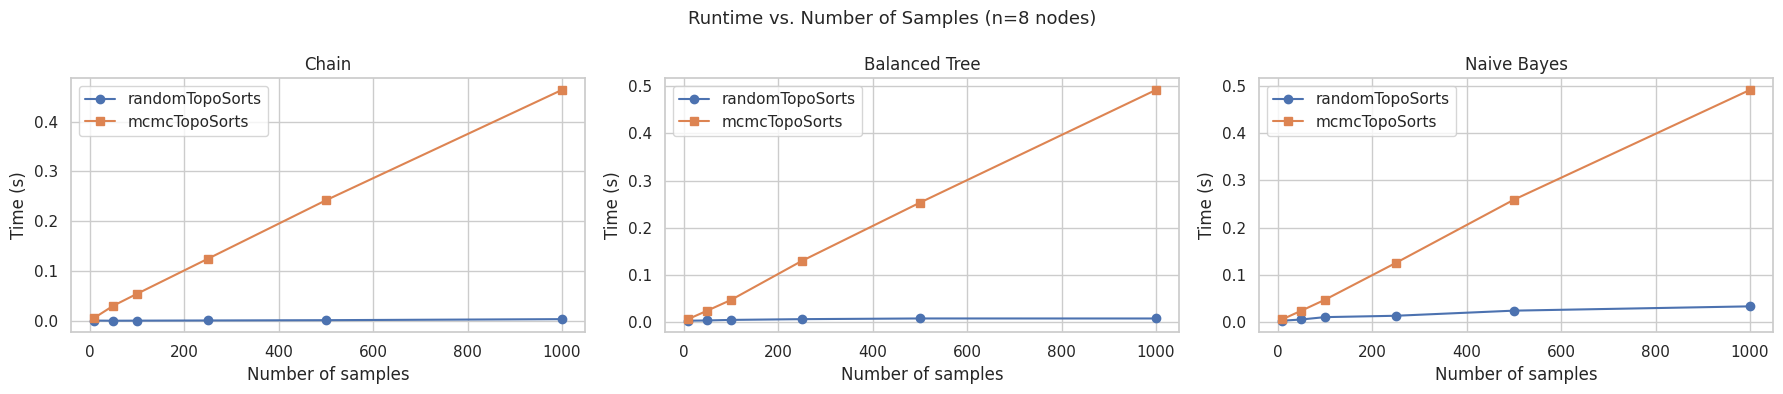

In [8]:
fig, axes = plt.subplots(1, len(graph_factories), figsize=(6 * len(graph_factories), 4), sharey=False)

for ax, (graph_name, _) in zip(axes, graph_factories.items()):
    sub = df_samples[df_samples['Graph'] == graph_name]
    ax.plot(sub['Samples'], sub['randomTopoSorts (s)'], marker='o', label='randomTopoSorts')
    ax.plot(sub['Samples'], sub['mcmcTopoSorts (s)'], marker='s', label='mcmcTopoSorts')
    ax.set_title(graph_name)
    ax.set_xlabel('Number of samples')
    ax.set_ylabel('Time (s)')
    ax.legend()

fig.suptitle(f'Runtime vs. Number of Samples (n={FIXED_N} nodes)', fontsize=13)
plt.tight_layout()
plt.show()

## Summary Table

In [9]:
print("=== Runtime by node count ===")
display(df_nodes.pivot_table(index=['Graph', 'Nodes'],
                              values=['randomTopoSorts (s)', 'mcmcTopoSorts (s)'],
                              aggfunc='first').round(4))

=== Runtime by node count ===


mcmcTopoSorts (s)  randomTopoSorts (s)
Graph         Nodes                                        
Balanced Tree 4                 0.0118               0.0004
              6                 0.0385               0.0014
              8                 0.1017               0.0041
              10                0.1925               0.0182
              12                0.3241               0.0282
              14                0.5434               0.0594
Chain         4                 0.0179               0.0028
              6                 0.0462               0.0009
              8                 0.0995               0.0010
              10                0.2286               0.0015
              12                0.3419               0.0019
              14                0.6253               0.0046
Naive Bayes   4                 0.0144               0.0006
              6                 0.0460               0.0023
              8                 0.1088               0.0133
              10                0.2058               0.0355
              12                0.3575               0.0914
              14                0.5090               0.3415

In [10]:
print("=== Runtime by sample count ===")
display(df_samples.pivot_table(index=['Graph', 'Samples'],
                                values=['randomTopoSorts (s)', 'mcmcTopoSorts (s)'],
                                aggfunc='first').round(4))

=== Runtime by sample count ===


mcmcTopoSorts (s)  randomTopoSorts (s)
Graph         Samples                                        
Balanced Tree 10                  0.0057               0.0021
              50                  0.0235               0.0026
              100                 0.0461               0.0038
              250                 0.1290               0.0054
              500                 0.2529               0.0068
              1000                0.4927               0.0068
Chain         10                  0.0065               0.0009
              50                  0.0307               0.0006
              100                 0.0545               0.0008
              250                 0.1248               0.0011
              500                 0.2421               0.0017
              1000                0.4636               0.0038
Naive Bayes   10                  0.0059               0.0028
              50                  0.0239               0.0054
              100                 0.0471               0.0104
              250                 0.1250               0.0133
              500                 0.2588               0.0241
              1000                0.4912               0.0332